In [1]:
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)



***Seeding***

In [6]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IMG_SIZE = 224
NUM_CLASSES = 37

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 5

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

NUM_WORKERS = 2


Dataset Loading 


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


full_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=True
)

test_dataset_full = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=eval_transform,
    download=True
)

100%|██████████| 792M/792M [00:34<00:00, 23.0MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.5MB/s]


In [8]:
total_size = len(full_dataset)

val_size = int(total_size * VAL_SPLIT)
train_size = total_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

# Validation should use evaluation transforms.
val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = eval_transform


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset_full,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset_full))

Training samples: 3128
Validation samples: 552
Test samples: 3669


Model Building

In [11]:
# ============================================================
# 4. MODEL
# MobileNetV2
# ============================================================

def build_model(
    init="he",
    reg="none",
    dropout=0.25,
    optimizer="adam",
    lr=0.001,
    pretrained=False,
    freeze_base=True,
    unfreeze_layers=0
):

    weights = (
        models.MobileNet_V2_Weights.DEFAULT
        if pretrained
        else None
    )

    model = models.mobilenet_v2(weights=weights)

    # --------------------------------------------------------
    # Freeze / unfreeze base
    # --------------------------------------------------------

    if pretrained and freeze_base:
        for param in model.features.parameters():
            param.requires_grad = False

    if pretrained and unfreeze_layers > 0:
        layers = list(model.features.children())

        for layer in layers[-unfreeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    in_features = model.classifier[1].in_features

    classifier_layers = []

    classifier_layers.append(
        nn.Dropout(dropout)
    )

    classifier_layers.append(
        nn.Linear(in_features, NUM_CLASSES)
    )

    model.classifier = nn.Sequential(*classifier_layers)

    # --------------------------------------------------------
    # Weight initialization
    # --------------------------------------------------------

    if not pretrained:

        for module in model.modules():

            if isinstance(module, nn.Linear):

                if init == "zero":
                    nn.init.constant_(module.weight, 0)
                    if module.bias is not None:
                        nn.init.constant_(module.bias, 0)

                elif init == "random":
                    nn.init.normal_(
                        module.weight,
                        mean=0.0,
                        std=0.05
                    )

                elif init == "xavier":
                    nn.init.xavier_uniform_(module.weight)

                elif init == "he":
                    nn.init.kaiming_uniform_(
                        module.weight,
                        nonlinearity="relu"
                    )

                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    return model.to(device)


In [12]:

def get_optimizer(model, optimizer_name, lr=0.001):

    parameters = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    if optimizer_name == "sgd":

        return optim.SGD(
            parameters,
            lr=lr
        )

    elif optimizer_name == "momentum":

        return optim.SGD(
            parameters,
            lr=lr,
            momentum=0.9
        )

    elif optimizer_name == "rmsprop":

        return optim.RMSprop(
            parameters,
            lr=lr
        )

    elif optimizer_name == "adam":

        return optim.Adam(
            parameters,
            lr=lr
        )

    else:
        raise ValueError("Unknown optimizer")



In [13]:

def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy, all_labels, all_preds


In [14]:
def fit_model(
    model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    optimizer_name="adam",
    weight_decay=0.0
):

    criterion = nn.CrossEntropyLoss()

    optimizer = get_optimizer(
        model,
        optimizer_name,
        lr
    )

    if weight_decay > 0:

        for group in optimizer.param_groups:
            group["weight_decay"] = weight_decay

    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion
        )

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        if val_acc > best_val_acc:

            best_val_acc = val_acc
            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc * 100:.2f}% | "
            f"Val Acc: {val_acc * 100:.2f}%"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history



In [15]:
def line_plot(histories, key, title, ylabel, pct=False):

    plt.figure(figsize=(7, 5))

    for label, history in histories.items():

        values = history[key]

        if pct:
            values = [v * 100 for v in values]

        plt.plot(
            range(1, len(values) + 1),
            values,
            marker="o",
            label=label
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()


def bar_plot(x_vals, y_vals, xlabel, title):

    plt.figure(figsize=(6, 5))

    plt.plot(
        [str(v) for v in x_vals],
        [v * 100 for v in y_vals],
        marker="o"
    )

    plt.xlabel(xlabel)
    plt.ylabel("Validation Accuracy (%)")
    plt.title(title)

    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()



Training with zero initialization...
Epoch 1/5 | Loss: 3.6360 | Train Acc: 4.09% | Val Acc: 4.89%
Epoch 2/5 | Loss: 3.5287 | Train Acc: 4.96% | Val Acc: 4.53%
Epoch 3/5 | Loss: 3.4596 | Train Acc: 5.98% | Val Acc: 5.43%
Epoch 4/5 | Loss: 3.4106 | Train Acc: 6.52% | Val Acc: 5.25%
Epoch 5/5 | Loss: 3.3421 | Train Acc: 8.41% | Val Acc: 6.70%

Training with random initialization...
Epoch 1/5 | Loss: 3.7884 | Train Acc: 4.80% | Val Acc: 5.62%
Epoch 2/5 | Loss: 3.5750 | Train Acc: 7.48% | Val Acc: 9.24%
Epoch 3/5 | Loss: 3.3449 | Train Acc: 11.60% | Val Acc: 7.25%
Epoch 4/5 | Loss: 3.1971 | Train Acc: 12.92% | Val Acc: 12.32%
Epoch 5/5 | Loss: 3.0270 | Train Acc: 16.53% | Val Acc: 14.13%

Training with xavier initialization...
Epoch 1/5 | Loss: 3.7475 | Train Acc: 5.27% | Val Acc: 3.44%
Epoch 2/5 | Loss: 3.5726 | Train Acc: 7.38% | Val Acc: 7.07%
Epoch 3/5 | Loss: 3.3791 | Train Acc: 9.59% | Val Acc: 10.87%
Epoch 4/5 | Loss: 3.2374 | Train Acc: 11.57% | Val Acc: 11.59%
Epoch 5/5 | Loss: 3.

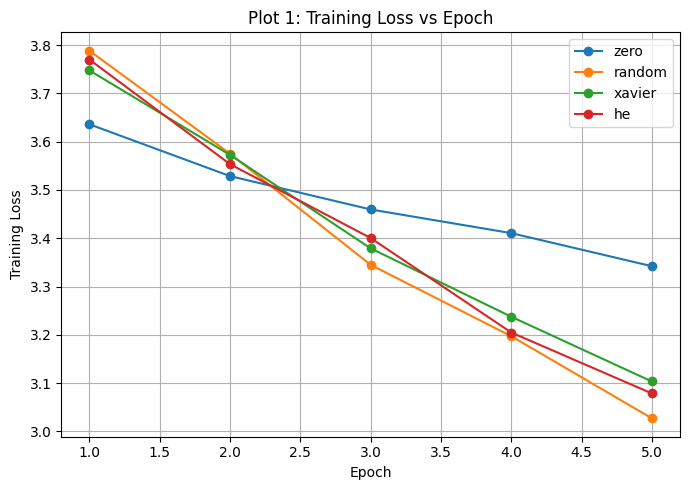

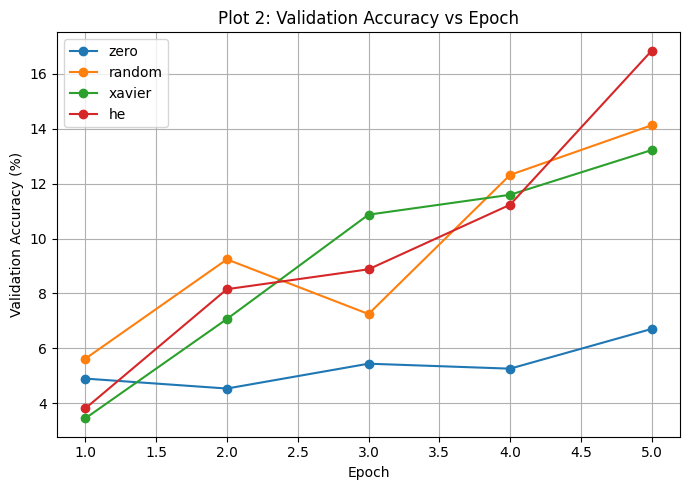


Best initialization: he


In [16]:

initializations = [
    "zero",
    "random",
    "xavier",
    "he"
]

init_hist = {}

for init in initializations:

    print(f"\nTraining with {init} initialization...")

    model = build_model(
        init=init,
        reg="none",
        optimizer="adam",
        lr=0.001
    )

    history = fit_model(
        model,
        epochs=EPOCHS,
        lr=0.001,
        optimizer_name="adam"
    )

    init_hist[init] = history


# Plot 1
line_plot(
    init_hist,
    "loss",
    "Plot 1: Training Loss vs Epoch",
    "Training Loss"
)


# Plot 2
line_plot(
    init_hist,
    "val_accuracy",
    "Plot 2: Validation Accuracy vs Epoch",
    "Validation Accuracy (%)",
    pct=True
)


best_init = max(
    initializations,
    key=lambda x: max(init_hist[x]["val_accuracy"])
)

print("\nBest initialization:", best_init)


Training with None...
Epoch 1/5 | Loss: 3.7122 | Train Acc: 4.73% | Val Acc: 4.89%
Epoch 2/5 | Loss: 3.5040 | Train Acc: 7.51% | Val Acc: 5.98%
Epoch 3/5 | Loss: 3.2917 | Train Acc: 10.71% | Val Acc: 10.87%
Epoch 4/5 | Loss: 3.1310 | Train Acc: 14.03% | Val Acc: 12.50%
Epoch 5/5 | Loss: 2.9731 | Train Acc: 17.20% | Val Acc: 13.04%

Training with L2...
Epoch 1/5 | Loss: 3.7030 | Train Acc: 4.35% | Val Acc: 5.80%
Epoch 2/5 | Loss: 3.4569 | Train Acc: 8.86% | Val Acc: 9.96%
Epoch 3/5 | Loss: 3.2791 | Train Acc: 13.08% | Val Acc: 12.14%
Epoch 4/5 | Loss: 3.0897 | Train Acc: 14.80% | Val Acc: 13.22%
Epoch 5/5 | Loss: 2.9181 | Train Acc: 18.29% | Val Acc: 18.12%

Training with Dropout...
Epoch 1/5 | Loss: 3.7657 | Train Acc: 3.96% | Val Acc: 4.53%
Epoch 2/5 | Loss: 3.5635 | Train Acc: 6.87% | Val Acc: 8.51%
Epoch 3/5 | Loss: 3.3719 | Train Acc: 10.29% | Val Acc: 12.14%
Epoch 4/5 | Loss: 3.1797 | Train Acc: 13.30% | Val Acc: 11.41%
Epoch 5/5 | Loss: 3.0216 | Train Acc: 16.21% | Val Acc: 14.3

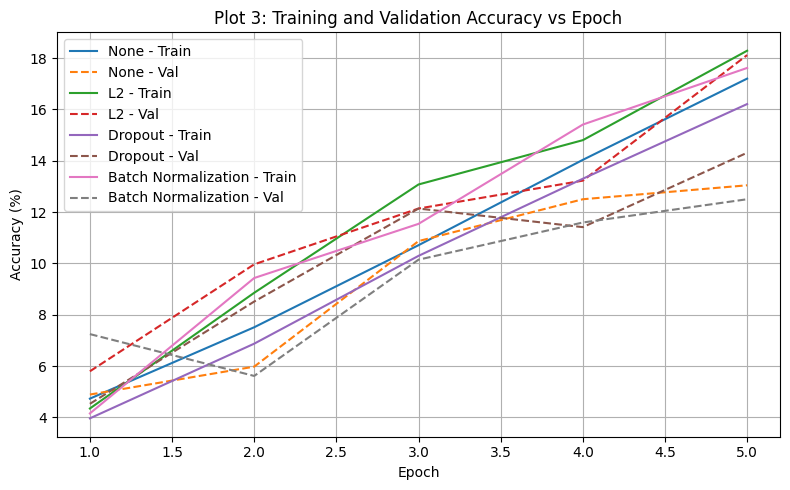

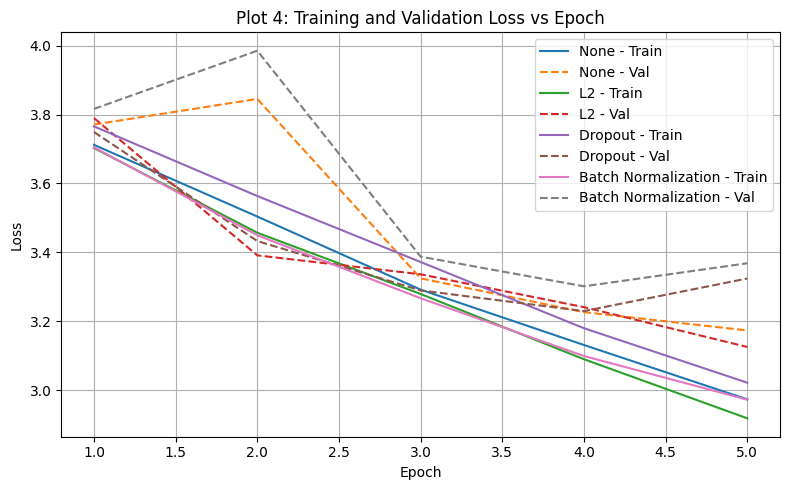


Best regularization: L2


In [17]:

regularization_configs = {
    "None": {
        "dropout": 0.0,
        "weight_decay": 0.0
    },

    "L2": {
        "dropout": 0.0,
        "weight_decay": 1e-4
    },

    "Dropout": {
        "dropout": 0.25,
        "weight_decay": 0.0
    },

    "Batch Normalization": {
        "dropout": 0.0,
        "weight_decay": 0.0
    }
}

reg_hist = {}

for name, config in regularization_configs.items():

    print(f"\nTraining with {name}...")

    model = build_model(
        init=best_init,
        dropout=config["dropout"],
        optimizer="adam",
        lr=0.001
    )

    # MobileNetV2 already contains BatchNorm layers.
    history = fit_model(
        model,
        epochs=EPOCHS,
        lr=0.001,
        optimizer_name="adam",
        weight_decay=config["weight_decay"]
    )

    reg_hist[name] = history


# Plot 3
accuracy_histories = {}

for name, history in reg_hist.items():

    accuracy_histories[name + " - Train"] = {
        "accuracy": history["accuracy"]
    }

    accuracy_histories[name + " - Val"] = {
        "accuracy": history["val_accuracy"]
    }


plt.figure(figsize=(8, 5))

for name, history in reg_hist.items():

    plt.plot(
        range(1, len(history["accuracy"]) + 1),
        [v * 100 for v in history["accuracy"]],
        label=f"{name} - Train"
    )

    plt.plot(
        range(1, len(history["val_accuracy"]) + 1),
        [v * 100 for v in history["val_accuracy"]],
        linestyle="--",
        label=f"{name} - Val"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Plot 3: Training and Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


# Plot 4

plt.figure(figsize=(8, 5))

for name, history in reg_hist.items():

    plt.plot(
        range(1, len(history["loss"]) + 1),
        history["loss"],
        label=f"{name} - Train"
    )

    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        linestyle="--",
        label=f"{name} - Val"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 4: Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


best_reg = max(
    regularization_configs.keys(),
    key=lambda x: max(reg_hist[x]["val_accuracy"])
)

print("\nBest regularization:", best_reg)



Training with Batch Normalization...
Epoch 1/5 | Loss: 3.7466 | Train Acc: 4.41% | Val Acc: 5.25%
Epoch 2/5 | Loss: 3.5516 | Train Acc: 7.64% | Val Acc: 8.33%
Epoch 3/5 | Loss: 3.3686 | Train Acc: 10.07% | Val Acc: 11.96%
Epoch 4/5 | Loss: 3.1907 | Train Acc: 13.59% | Val Acc: 11.59%
Epoch 5/5 | Loss: 3.0437 | Train Acc: 15.76% | Val Acc: 16.12%

Training without Batch Normalization...
Epoch 1/5 | Loss: 3.6114 | Train Acc: 2.21% | Val Acc: 1.81%
Epoch 2/5 | Loss: 3.6112 | Train Acc: 2.53% | Val Acc: 1.81%
Epoch 3/5 | Loss: 3.6111 | Train Acc: 2.24% | Val Acc: 1.81%
Epoch 4/5 | Loss: 3.6110 | Train Acc: 2.88% | Val Acc: 1.81%
Epoch 5/5 | Loss: 3.6109 | Train Acc: 2.59% | Val Acc: 1.81%


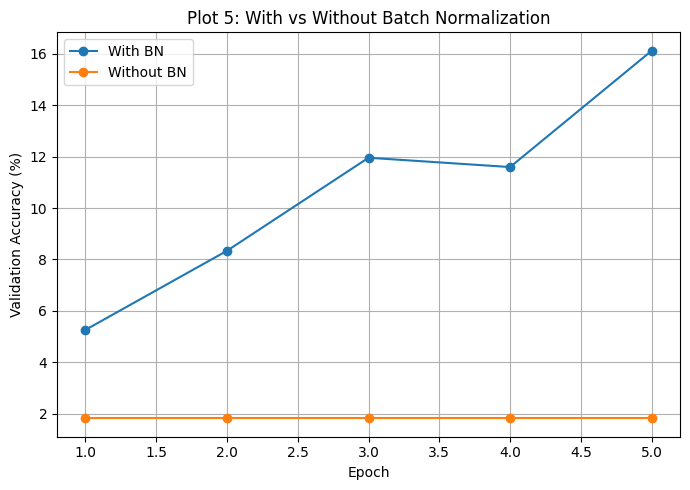

In [18]:

def remove_batch_norm(model):

    for name, module in model.named_children():

        if isinstance(module, nn.BatchNorm2d):

            setattr(
                model,
                name,
                nn.Identity()
            )

        else:
            remove_batch_norm(module)

    return model


bn_model = build_model(
    init=best_init,
    optimizer="adam",
    lr=0.001
)

without_bn_model = build_model(
    init=best_init,
    optimizer="adam",
    lr=0.001
)

without_bn_model = remove_batch_norm(
    without_bn_model
)

print("\nTraining with Batch Normalization...")

bn_hist = fit_model(
    bn_model,
    epochs=EPOCHS,
    lr=0.001,
    optimizer_name="adam"
)

print("\nTraining without Batch Normalization...")

without_bn_hist = fit_model(
    without_bn_model,
    epochs=EPOCHS,
    lr=0.001,
    optimizer_name="adam"
)


plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    [v * 100 for v in bn_hist["val_accuracy"]],
    marker="o",
    label="With BN"
)

plt.plot(
    range(1, EPOCHS + 1),
    [v * 100 for v in without_bn_hist["val_accuracy"]],
    marker="o",
    label="Without BN"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Training with SGD...
Epoch 1/5 | Loss: 3.7049 | Train Acc: 2.37% | Val Acc: 3.26%
Epoch 2/5 | Loss: 3.6317 | Train Acc: 2.72% | Val Acc: 3.26%
Epoch 3/5 | Loss: 3.6088 | Train Acc: 3.23% | Val Acc: 4.17%
Epoch 4/5 | Loss: 3.5922 | Train Acc: 3.77% | Val Acc: 4.53%
Epoch 5/5 | Loss: 3.5798 | Train Acc: 4.22% | Val Acc: 2.72%

Training with Momentum...
Epoch 1/5 | Loss: 3.6590 | Train Acc: 2.97% | Val Acc: 2.90%
Epoch 2/5 | Loss: 3.6023 | Train Acc: 4.38% | Val Acc: 2.54%
Epoch 3/5 | Loss: 3.5549 | Train Acc: 5.12% | Val Acc: 5.25%
Epoch 4/5 | Loss: 3.4868 | Train Acc: 6.59% | Val Acc: 5.98%
Epoch 5/5 | Loss: 3.4269 | Train Acc: 7.51% | Val Acc: 5.80%

Training with RMSProp...
Epoch 1/5 | Loss: 3.8181 | Train Acc: 4.70% | Val Acc: 6.70%
Epoch 2/5 | Loss: 3.3773 | Train Acc: 8.57% | Val Acc: 7.79%
Epoch 3/5 | Loss: 3.2329 | Train Acc: 11.76% | Val Acc: 9.42%
Epoch 4/5 | Loss: 3.0967 | Train Acc: 13.33% | Val Acc: 10.33%
Epoch 5/5 | Loss: 2.9578 | Train Acc: 16.98% | Val Acc: 12.50%

Trai

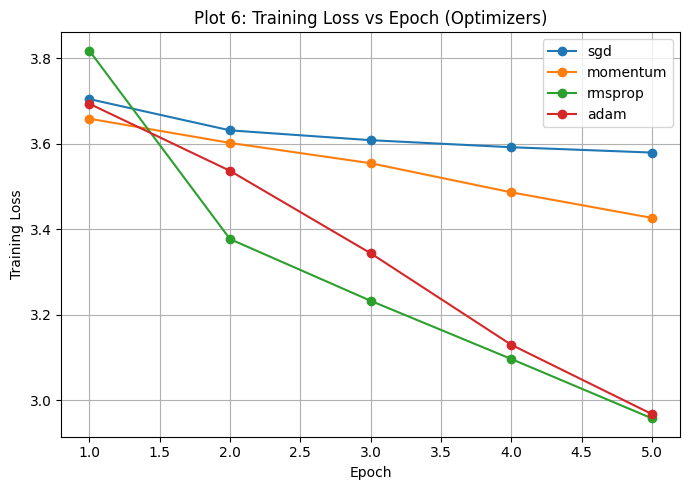

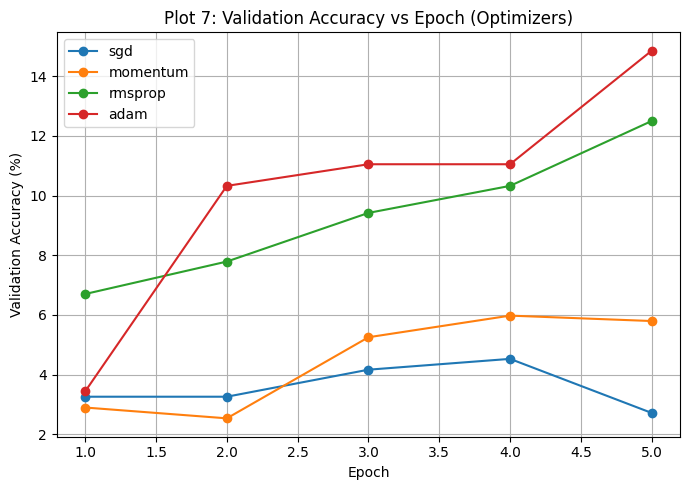


Optimizer Results:
Optimizer  Final Loss  Best Val. Accuracy  Epoch to Converge  Time (s)
      SGD      3.5798                4.53                  4     75.09
 Momentum      3.4269                5.98                  4     75.00
  RMSProp      2.9578               12.50                  5     75.16
     Adam      2.9678               14.86                  5     75.33

Best optimizer: Adam


In [19]:
optimizers_list = [
    "sgd",
    "momentum",
    "rmsprop",
    "adam"
]

opt_labels = {
    "sgd": "SGD",
    "momentum": "Momentum",
    "rmsprop": "RMSProp",
    "adam": "Adam"
}

opt_hist = {}
opt_time = {}

for opt in optimizers_list:

    print(f"\nTraining with {opt_labels[opt]}...")

    model = build_model(
        init=best_init,
        dropout=0.0,
        optimizer=opt,
        lr=0.001
    )

    t0 = time.time()

    history = fit_model(
        model,
        epochs=EPOCHS,
        lr=0.001,
        optimizer_name=opt
    )

    opt_time[opt] = time.time() - t0
    opt_hist[opt] = history


# Plot 6
line_plot(
    opt_hist,
    "loss",
    "Plot 6: Training Loss vs Epoch (Optimizers)",
    "Training Loss"
)


# Plot 7
line_plot(
    opt_hist,
    "val_accuracy",
    "Plot 7: Validation Accuracy vs Epoch (Optimizers)",
    "Validation Accuracy (%)",
    pct=True
)


opt_table = pd.DataFrame([
    {
        "Optimizer": opt_labels[o],
        "Final Loss": round(
            opt_hist[o]["loss"][-1],
            4
        ),
        "Best Val. Accuracy": round(
            max(opt_hist[o]["val_accuracy"]) * 100,
            2
        ),
        "Epoch to Converge":
            opt_hist[o]["val_accuracy"].index(
                max(opt_hist[o]["val_accuracy"])
            ) + 1,
        "Time (s)": round(
            opt_time[o],
            2
        )
    }

    for o in optimizers_list
])

print("\nOptimizer Results:")
print(opt_table.to_string(index=False))

best_opt = opt_table.loc[
    opt_table["Best Val. Accuracy"].idxmax(),
    "Optimizer"
]

best_opt_key = [
    k for k, v in opt_labels.items()
    if v == best_opt
][0]

print("\nBest optimizer:", best_opt)



Learning rate: 0.001
Epoch 1/5 | Loss: 3.7864 | Train Acc: 3.96% | Val Acc: 5.07%
Epoch 2/5 | Loss: 3.6016 | Train Acc: 6.46% | Val Acc: 7.07%
Epoch 3/5 | Loss: 3.3762 | Train Acc: 9.72% | Val Acc: 10.69%
Epoch 4/5 | Loss: 3.2145 | Train Acc: 12.66% | Val Acc: 11.23%
Epoch 5/5 | Loss: 3.0454 | Train Acc: 15.44% | Val Acc: 13.95%

Learning rate: 0.0001
Epoch 1/5 | Loss: 3.6482 | Train Acc: 3.13% | Val Acc: 4.53%
Epoch 2/5 | Loss: 3.6040 | Train Acc: 4.12% | Val Acc: 5.07%
Epoch 3/5 | Loss: 3.5515 | Train Acc: 5.02% | Val Acc: 6.52%
Epoch 4/5 | Loss: 3.4894 | Train Acc: 6.91% | Val Acc: 7.43%
Epoch 5/5 | Loss: 3.4234 | Train Acc: 8.70% | Val Acc: 7.25%


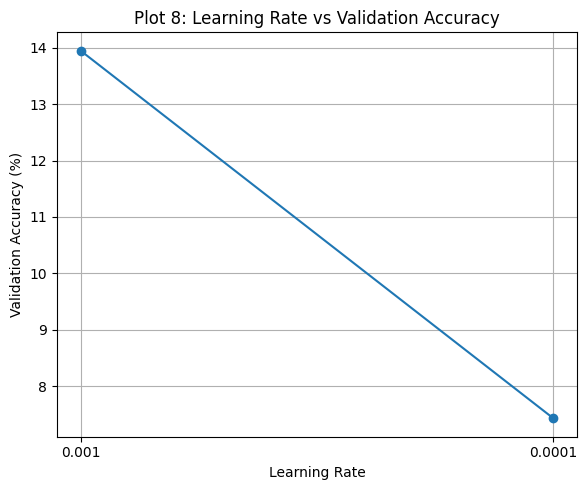


Batch size: 16
Epoch 1/5 | Loss: 3.7949 | Train Acc: 4.51% | Val Acc: 6.88%
Epoch 2/5 | Loss: 3.5349 | Train Acc: 8.02% | Val Acc: 10.14%
Epoch 3/5 | Loss: 3.3404 | Train Acc: 9.94% | Val Acc: 9.42%
Epoch 4/5 | Loss: 3.1997 | Train Acc: 11.80% | Val Acc: 12.50%
Epoch 5/5 | Loss: 3.0484 | Train Acc: 15.63% | Val Acc: 13.22%

Batch size: 32
Epoch 1/5 | Loss: 3.7567 | Train Acc: 4.96% | Val Acc: 5.43%
Epoch 2/5 | Loss: 3.5248 | Train Acc: 7.19% | Val Acc: 7.43%
Epoch 3/5 | Loss: 3.3114 | Train Acc: 10.42% | Val Acc: 11.23%
Epoch 4/5 | Loss: 3.1443 | Train Acc: 13.94% | Val Acc: 13.22%
Epoch 5/5 | Loss: 2.9941 | Train Acc: 17.84% | Val Acc: 13.77%

Batch size: 64
Epoch 1/5 | Loss: 3.7110 | Train Acc: 4.54% | Val Acc: 1.81%
Epoch 2/5 | Loss: 3.5536 | Train Acc: 6.78% | Val Acc: 8.33%
Epoch 3/5 | Loss: 3.3984 | Train Acc: 9.27% | Val Acc: 8.15%
Epoch 4/5 | Loss: 3.2016 | Train Acc: 12.98% | Val Acc: 9.78%
Epoch 5/5 | Loss: 3.0703 | Train Acc: 16.24% | Val Acc: 12.14%


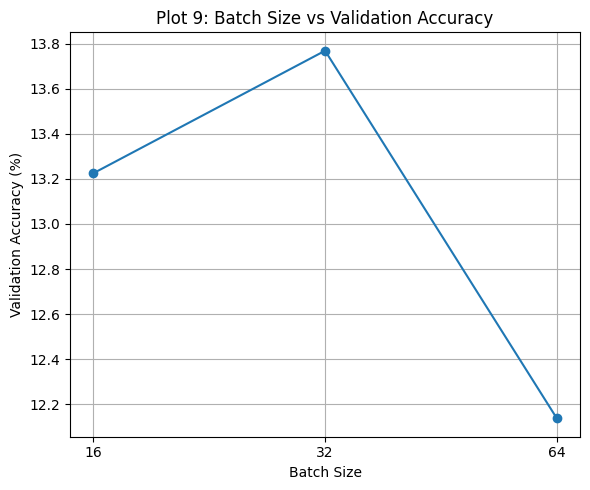


Dropout: 0.0
Epoch 1/5 | Loss: 3.6936 | Train Acc: 5.12% | Val Acc: 4.53%
Epoch 2/5 | Loss: 3.4948 | Train Acc: 7.38% | Val Acc: 4.89%
Epoch 3/5 | Loss: 3.3419 | Train Acc: 10.81% | Val Acc: 12.50%
Epoch 4/5 | Loss: 3.1533 | Train Acc: 13.62% | Val Acc: 11.59%
Epoch 5/5 | Loss: 3.0137 | Train Acc: 16.24% | Val Acc: 13.77%

Dropout: 0.25
Epoch 1/5 | Loss: 3.7377 | Train Acc: 4.76% | Val Acc: 5.07%
Epoch 2/5 | Loss: 3.5388 | Train Acc: 7.64% | Val Acc: 5.07%
Epoch 3/5 | Loss: 3.3722 | Train Acc: 10.23% | Val Acc: 10.51%
Epoch 4/5 | Loss: 3.2121 | Train Acc: 12.18% | Val Acc: 12.50%
Epoch 5/5 | Loss: 3.0416 | Train Acc: 16.11% | Val Acc: 13.41%

Dropout: 0.5
Epoch 1/5 | Loss: 3.8733 | Train Acc: 3.71% | Val Acc: 4.35%
Epoch 2/5 | Loss: 3.6804 | Train Acc: 6.11% | Val Acc: 6.88%
Epoch 3/5 | Loss: 3.5071 | Train Acc: 6.91% | Val Acc: 9.60%
Epoch 4/5 | Loss: 3.3295 | Train Acc: 10.42% | Val Acc: 9.96%
Epoch 5/5 | Loss: 3.1440 | Train Acc: 14.87% | Val Acc: 13.41%


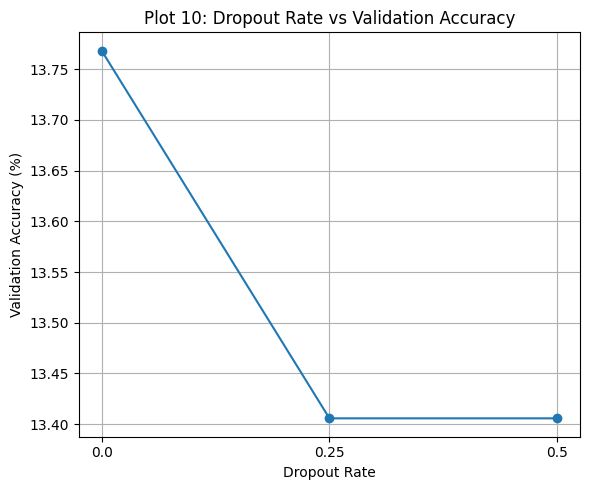


Best hyperparameters: lr=0.001, batch_size=32, dropout=0.0


In [20]:
def val_acc_for(
    lr=0.001,
    batch=32,
    dropout=0.25
):

    model = build_model(
        init=best_init,
        dropout=dropout,
        optimizer=best_opt_key,
        lr=lr
    )

    temp_train_loader = DataLoader(
        train_dataset,
        batch_size=batch,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    temp_val_loader = DataLoader(
        val_dataset,
        batch_size=batch,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    history = fit_model(
        model,
        train_loader=temp_train_loader,
        val_loader=temp_val_loader,
        epochs=EPOCHS,
        lr=lr,
        optimizer_name=best_opt_key
    )

    return max(history["val_accuracy"])


# ------------------------------------------------------------
# Learning Rate
# ------------------------------------------------------------

lr_values = [
    0.001,
    0.0001
]

lr_acc = []

for value in lr_values:

    print(f"\nLearning rate: {value}")

    lr_acc.append(
        val_acc_for(lr=value)
    )


bar_plot(
    lr_values,
    lr_acc,
    "Learning Rate",
    "Plot 8: Learning Rate vs Validation Accuracy"
)


# ------------------------------------------------------------
# Batch Size
# ------------------------------------------------------------

batch_values = [
    16,
    32,
    64
]

batch_acc = []

for value in batch_values:

    print(f"\nBatch size: {value}")

    batch_acc.append(
        val_acc_for(batch=value)
    )


bar_plot(
    batch_values,
    batch_acc,
    "Batch Size",
    "Plot 9: Batch Size vs Validation Accuracy"
)


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

dropout_values = [
    0.0,
    0.25,
    0.5
]

dropout_acc = []

for value in dropout_values:

    print(f"\nDropout: {value}")

    dropout_acc.append(
        val_acc_for(dropout=value)
    )


bar_plot(
    dropout_values,
    dropout_acc,
    "Dropout Rate",
    "Plot 10: Dropout Rate vs Validation Accuracy"
)


best_lr = lr_values[
    int(np.argmax(lr_acc))
]

best_batch = batch_values[
    int(np.argmax(batch_acc))
]

best_dropout = dropout_values[
    int(np.argmax(dropout_acc))
]

print(
    f"\nBest hyperparameters: "
    f"lr={best_lr}, "
    f"batch_size={best_batch}, "
    f"dropout={best_dropout}"
)



Feature Extraction
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 179MB/s]


Epoch 1/5 | Loss: 2.1979 | Train Acc: 58.73% | Val Acc: 79.71%
Epoch 2/5 | Loss: 0.9417 | Train Acc: 84.49% | Val Acc: 84.24%
Epoch 3/5 | Loss: 0.6347 | Train Acc: 89.03% | Val Acc: 84.96%
Epoch 4/5 | Loss: 0.4915 | Train Acc: 91.24% | Val Acc: 84.60%
Epoch 5/5 | Loss: 0.4085 | Train Acc: 92.62% | Val Acc: 86.41%

Fine-Tuning
Epoch 1/5 | Loss: 2.9794 | Train Acc: 43.45% | Val Acc: 74.82%
Epoch 2/5 | Loss: 1.4372 | Train Acc: 81.43% | Val Acc: 84.42%
Epoch 3/5 | Loss: 0.7854 | Train Acc: 86.48% | Val Acc: 85.87%
Epoch 4/5 | Loss: 0.5470 | Train Acc: 88.87% | Val Acc: 87.32%
Epoch 5/5 | Loss: 0.3984 | Train Acc: 92.04% | Val Acc: 88.22%


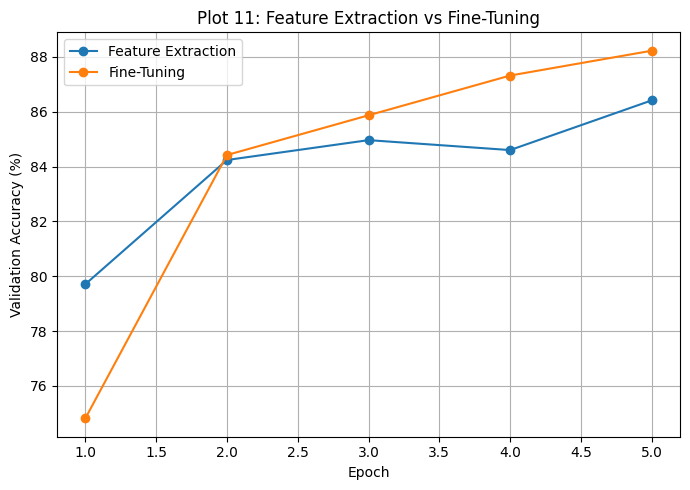

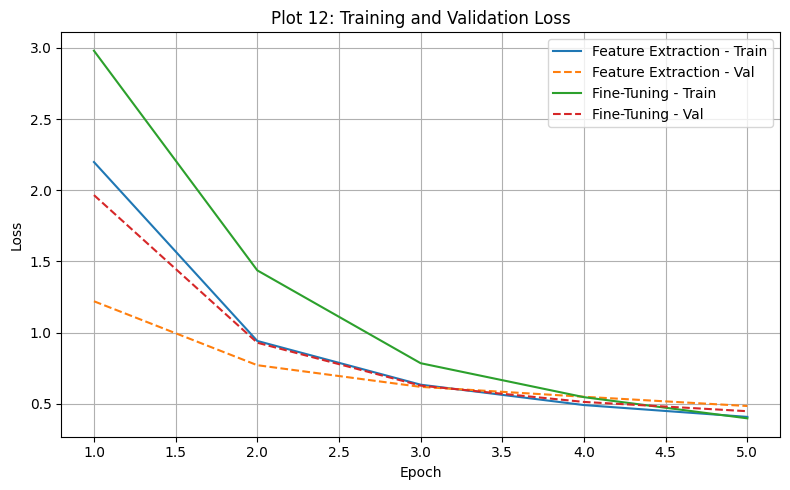

In [21]:


# ------------------------------------------------------------
# CASE A: FEATURE EXTRACTION
# ------------------------------------------------------------

print("\nFeature Extraction")

feature_model = build_model(
    pretrained=True,
    freeze_base=True,
    dropout=best_dropout,
    optimizer=best_opt_key,
    lr=best_lr
)

feature_hist = fit_model(
    feature_model,
    epochs=EPOCHS,
    lr=best_lr,
    optimizer_name=best_opt_key
)


# ------------------------------------------------------------
# CASE B: FINE-TUNING
# ------------------------------------------------------------

print("\nFine-Tuning")

fine_tune_model = build_model(
    pretrained=True,
    freeze_base=True,
    unfreeze_layers=4,
    dropout=best_dropout,
    optimizer=best_opt_key,
    lr=0.0001
)

fine_tune_hist = fit_model(
    fine_tune_model,
    epochs=EPOCHS,
    lr=0.0001,
    optimizer_name=best_opt_key
)


# ------------------------------------------------------------
# Plot 11
# ------------------------------------------------------------

line_plot(
    {
        "Feature Extraction": feature_hist,
        "Fine-Tuning": fine_tune_hist
    },
    "val_accuracy",
    "Plot 11: Feature Extraction vs Fine-Tuning",
    "Validation Accuracy (%)",
    pct=True
)


# ------------------------------------------------------------
# Plot 12
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    feature_hist["loss"],
    label="Feature Extraction - Train"
)

plt.plot(
    range(1, EPOCHS + 1),
    feature_hist["val_loss"],
    linestyle="--",
    label="Feature Extraction - Val"
)

plt.plot(
    range(1, EPOCHS + 1),
    fine_tune_hist["loss"],
    label="Fine-Tuning - Train"
)

plt.plot(
    range(1, EPOCHS + 1),
    fine_tune_hist["val_loss"],
    linestyle="--",
    label="Fine-Tuning - Val"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


In [22]:

configs = [
    {
        "name": "C1",
        "lr": best_lr,
        "batch": best_batch,
        "dropout": best_dropout
    },

    {
        "name": "C2",
        "lr": 0.001,
        "batch": 32,
        "dropout": 0.25
    },

    {
        "name": "C3",
        "lr": 0.0001,
        "batch": 32,
        "dropout": 0.25
    },

    {
        "name": "C4",
        "lr": best_lr,
        "batch": 16,
        "dropout": best_dropout
    }
]


# Use a smaller subset if computational resources are limited.
# Set CV_LIMIT = None to use the complete training dataset.

CV_LIMIT = None

indices = np.arange(len(train_dataset))

if CV_LIMIT is not None:
    indices = indices[:CV_LIMIT]


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


cv_results = {}


for config in configs:

    print(
        f"\nRunning 5-fold CV for {config['name']}..."
    )

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(indices),
        start=1
    ):

        print(
            f"  Fold {fold}/5"
        )

        actual_train_idx = indices[train_idx]
        actual_val_idx = indices[val_idx]

        fold_train = Subset(
            train_dataset,
            actual_train_idx
        )

        fold_val = Subset(
            train_dataset,
            actual_val_idx
        )

        fold_train_loader = DataLoader(
            fold_train,
            batch_size=config["batch"],
            shuffle=True,
            num_workers=NUM_WORKERS
        )

        fold_val_loader = DataLoader(
            fold_val,
            batch_size=config["batch"],
            shuffle=False,
            num_workers=NUM_WORKERS
        )

        model = build_model(
            init=best_init,
            dropout=config["dropout"],
            optimizer=best_opt_key,
            lr=config["lr"]
        )

        history = fit_model(
            model,
            train_loader=fold_train_loader,
            val_loader=fold_val_loader,
            epochs=EPOCHS,
            lr=config["lr"],
            optimizer_name=best_opt_key
        )

        best_fold_accuracy = max(
            history["val_accuracy"]
        )

        fold_scores.append(
            best_fold_accuracy
        )

        print(
            f"    Fold accuracy: "
            f"{best_fold_accuracy * 100:.2f}%"
        )

    mean_acc = np.mean(fold_scores)
    std_acc = np.std(fold_scores)

    cv_results[config["name"]] = {
        "scores": fold_scores,
        "mean": mean_acc,
        "std": std_acc
    }




Running 5-fold CV for C1...
  Fold 1/5
Epoch 1/5 | Loss: 3.7053 | Train Acc: 4.28% | Val Acc: 4.31%
Epoch 2/5 | Loss: 3.5238 | Train Acc: 7.47% | Val Acc: 7.67%
Epoch 3/5 | Loss: 3.3491 | Train Acc: 9.91% | Val Acc: 8.63%
Epoch 4/5 | Loss: 3.1914 | Train Acc: 12.63% | Val Acc: 11.34%
Epoch 5/5 | Loss: 3.0360 | Train Acc: 15.55% | Val Acc: 9.74%
    Fold accuracy: 11.34%
  Fold 2/5
Epoch 1/5 | Loss: 3.7464 | Train Acc: 4.44% | Val Acc: 3.35%
Epoch 2/5 | Loss: 3.5161 | Train Acc: 7.67% | Val Acc: 6.87%
Epoch 3/5 | Loss: 3.3695 | Train Acc: 10.27% | Val Acc: 7.51%
Epoch 4/5 | Loss: 3.2425 | Train Acc: 12.11% | Val Acc: 12.14%
Epoch 5/5 | Loss: 3.0799 | Train Acc: 16.15% | Val Acc: 13.42%
    Fold accuracy: 13.42%
  Fold 3/5
Epoch 1/5 | Loss: 3.7278 | Train Acc: 4.00% | Val Acc: 3.83%
Epoch 2/5 | Loss: 3.5851 | Train Acc: 5.88% | Val Acc: 5.11%
Epoch 3/5 | Loss: 3.4093 | Train Acc: 8.99% | Val Acc: 8.15%
Epoch 4/5 | Loss: 3.2341 | Train Acc: 12.39% | Val Acc: 7.35%
Epoch 5/5 | Loss: 3.057


5-Fold Cross-Validation Results:
Configuration    F1    F2    F3    F4    F5  Mean   SD
           C1 11.34 13.42 13.58 11.84 15.04 13.04 1.32
           C2 11.18 12.46 13.58 12.80 13.12 12.63 0.81
           C3  8.79  6.23  5.27  7.04  6.72  6.81 1.15
           C4 12.14 14.22 14.06 13.60 13.76 13.56 0.74


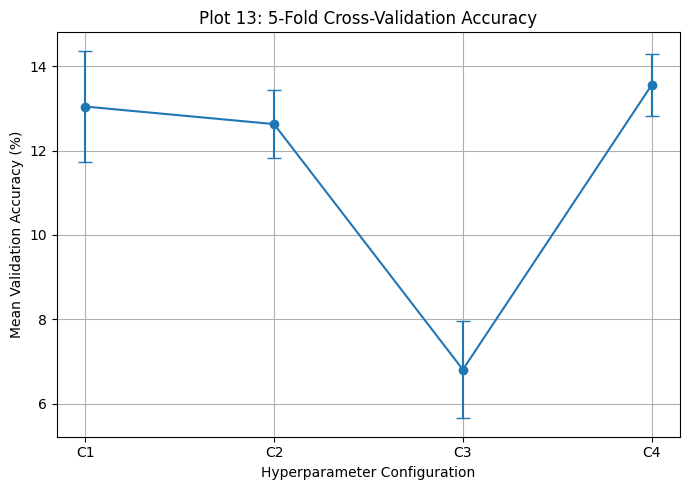


Best CV configuration: C4


In [23]:

cv_table = []

for name, result in cv_results.items():

    row = {
        "Configuration": name
    }

    for i, score in enumerate(
        result["scores"],
        start=1
    ):
        row[f"F{i}"] = round(
            score * 100,
            2
        )

    row["Mean"] = round(
        result["mean"] * 100,
        2
    )

    row["SD"] = round(
        result["std"] * 100,
        2
    )

    cv_table.append(row)


cv_table = pd.DataFrame(cv_table)

print("\n5-Fold Cross-Validation Results:")
print(
    cv_table.to_string(index=False)
)


# ------------------------------------------------------------
# Plot 13
# Mean Accuracy + Standard Deviation
# ------------------------------------------------------------

names = list(cv_results.keys())

means = [
    cv_results[name]["mean"] * 100
    for name in names
]

stds = [
    cv_results[name]["std"] * 100
    for name in names
]


plt.figure(figsize=(7, 5))

plt.errorbar(
    names,
    means,
    yerr=stds,
    fmt="o-",
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close()


# ------------------------------------------------------------
# SELECT BEST CV CONFIGURATION
# ------------------------------------------------------------

best_cv_config = max(
    cv_results.keys(),
    key=lambda x: cv_results[x]["mean"]
)

print(
    "\nBest CV configuration:",
    best_cv_config
)


In [24]:

selected_config = next(
    config
    for config in configs
    if config["name"] == best_cv_config
)


print("\nSelected configuration:")
print(selected_config)


# ------------------------------------------------------------
# Train final model
# ------------------------------------------------------------

final_model = build_model(
    init=best_init,
    dropout=selected_config["dropout"],
    optimizer=best_opt_key,
    lr=selected_config["lr"]
)


final_train_loader = DataLoader(
    train_dataset,
    batch_size=selected_config["batch"],
    shuffle=True,
    num_workers=NUM_WORKERS
)


final_start_time = time.time()

final_history = fit_model(
    final_model,
    train_loader=final_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=selected_config["lr"],
    optimizer_name=best_opt_key
)

training_time = time.time() - final_start_time



Selected configuration:
{'name': 'C4', 'lr': 0.001, 'batch': 16, 'dropout': 0.0}
Epoch 1/5 | Loss: 3.7599 | Train Acc: 5.63% | Val Acc: 3.99%
Epoch 2/5 | Loss: 3.5611 | Train Acc: 6.78% | Val Acc: 6.70%
Epoch 3/5 | Loss: 3.3456 | Train Acc: 9.69% | Val Acc: 10.51%
Epoch 4/5 | Loss: 3.1900 | Train Acc: 13.08% | Val Acc: 10.51%
Epoch 5/5 | Loss: 3.0631 | Train Acc: 15.28% | Val Acc: 14.67%


In [25]:
criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy, y_true, y_pred = evaluate(
    final_model,
    test_loader,
    criterion
)


precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

num_parameters = sum(
    p.numel()
    for p in final_model.parameters()
)


# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

mean_cv_accuracy = cv_results[
    best_cv_config
]["mean"]

cv_std = cv_results[
    best_cv_config
]["std"]


final_results = pd.DataFrame({
    "Metric": [
        "Mean CV Accuracy",
        "CV Standard Deviation",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)",
        "Number of Parameters"
    ],

    "Value": [
        f"{mean_cv_accuracy * 100:.2f}%",
        f"{cv_std * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{training_time:.2f}",
        f"{num_parameters:,}"
    ]
})


print("\nFINAL MODEL RESULTS")
print(
    final_results.to_string(index=False)
)



FINAL MODEL RESULTS
               Metric     Value
     Mean CV Accuracy    13.56%
CV Standard Deviation     0.74%
        Test Accuracy    14.88%
            Precision    13.25%
               Recall    14.88%
             F1-score    10.90%
    Training Time (s)     77.80
 Number of Parameters 2,271,269


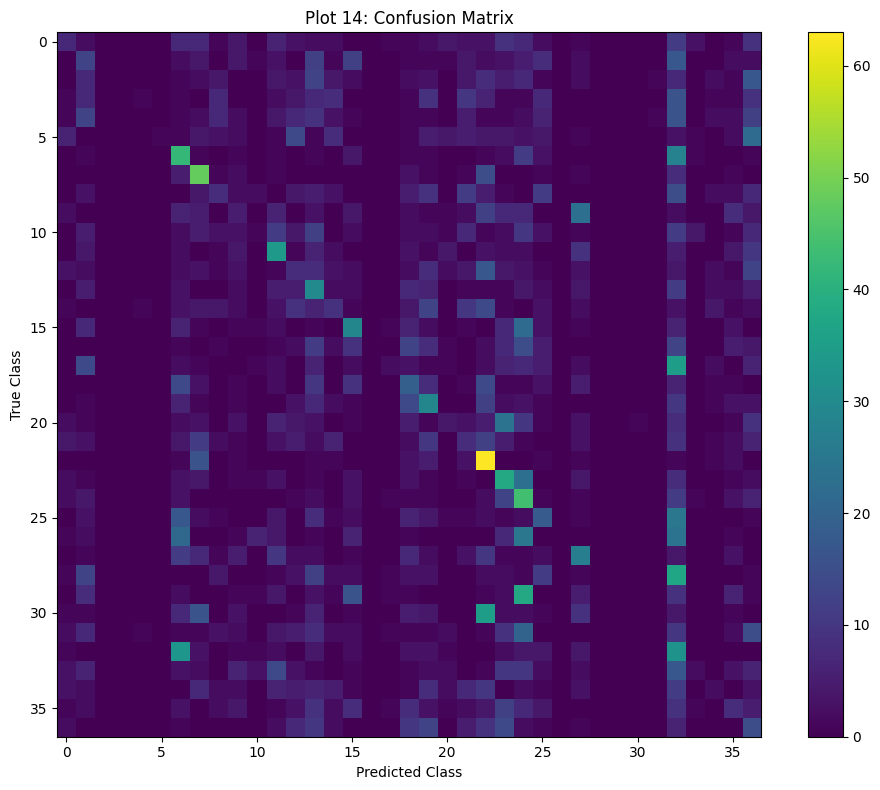

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Plot 14: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.colorbar()

plt.tight_layout()
plt.show()
plt.close()

In [27]:

print("Best Initialization:", best_init)
print("Best Regularization:", best_reg)
print("Best Optimizer:", best_opt)
print("Best Learning Rate:", best_lr)
print("Best Batch Size:", best_batch)
print("Best Dropout:", best_dropout)
print("Best CV Configuration:", best_cv_config)
print(
    "Final Test Accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

Best Initialization: he
Best Regularization: L2
Best Optimizer: Adam
Best Learning Rate: 0.001
Best Batch Size: 32
Best Dropout: 0.0
Best CV Configuration: C4
Final Test Accuracy: 14.88%
